# EXPLORATORY DATA ANALYSIS

## In this Notebook, I will be performing an EDA on the dataset.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
#from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset as excel file    

df = pd.read_excel('PSP_Jan_Feb_2019.xlsx', index_col=0)
df.head()

,tmsp,country,amount,success,PSP,3D_secured,card
0,2019-01-01 00:01:11,Germany,89,0,UK_Card,0,Visa
1,2019-01-01 00:01:17,Germany,89,1,UK_Card,0,Visa
2,2019-01-01 00:02:49,Germany,238,0,UK_Card,1,Diners
3,2019-01-01 00:03:13,Germany,238,1,UK_Card,1,Diners
4,2019-01-01 00:04:33,Austria,124,0,Simplecard,0,Diners


### Adding the Additional Information on the Fees

In [5]:
# Check if the data is sorted by timestamp
# Convert the 'tmsp' column to datetime format
df['tmsp'] = pd.to_datetime(df['tmsp'], format='%Y-%m-%d %H:%M:%S')

# Check if the timestamps are sorted in ascending order
is_sorted = df['tmsp'].is_monotonic_increasing

if is_sorted:
    print("The data is sorted by timestamp in ascending order.")
else:
    print("The data is not sorted by timestamp in ascending order.")

The data is sorted by timestamp in ascending order.


In [6]:
# Define the fee structure
fee_structure = {
    'UK_Card': {'success': 3, 'failure': 1},
    'Simplecard': {'success': 1, 'failure': 0.5},
    'Moneycard': {'success': 5, 'failure': 2},
    'Goldcard': {'success': 10, 'failure': 5}
}

# Add transaction fee columns
df['transaction_fee_success'] = df.apply(lambda row: fee_structure.get(row['PSP'], {'success': 0})['success'] if row['success'] == 1 else 0, axis=1)
df['transaction_fee_failure'] = df.apply(lambda row: fee_structure.get(row['PSP'], {'failure': 0})['failure'] if row['success'] == 0 else 0, axis=1)
df.head()

,tmsp,country,amount,success,PSP,3D_secured,card,transaction_fee_success,transaction_fee_failure
0,2019-01-01 00:01:11,Germany,89,0,UK_Card,0,Visa,0,1.0
1,2019-01-01 00:01:17,Germany,89,1,UK_Card,0,Visa,3,0.0
2,2019-01-01 00:02:49,Germany,238,0,UK_Card,1,Diners,0,1.0
3,2019-01-01 00:03:13,Germany,238,1,UK_Card,1,Diners,3,0.0
4,2019-01-01 00:04:33,Austria,124,0,Simplecard,0,Diners,0,0.5


In [5]:
# Let's look at the descriptive statistics
df.describe()

,amount,success,3D_secured,transaction_fee_success,transaction_fee_failure
count,50410.000000,50410.000000,50410.000000,50410.000000,50410.000000
mean,202.395715,0.202896,0.238266,0.783555,0.972922
std,96.274730,0.402160,0.426027,1.956557,0.993667
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,133.000000,0.000000,0.000000,0.000000,0.500000
50%,201.000000,0.000000,0.000000,0.000000,1.000000
75%,269.000000,0.000000,0.000000,0.000000,1.000000
max,630.000000,1.000000,1.000000,10.000000,5.000000


#### We see that the time of transaction spans from January 1, 2019 to February 28, 2019. We will be using this time period to train the model.

### The new dataframe now contains the transaction fee information. I'll use these information to create new features later, under feature engineering

In [6]:
data = df.copy()

### Let's assess the data for missing values, outliers, inconsistencies, and other quality issues that might impact the model's performance

In [7]:
# Check for missing values
print(data.isnull().sum())

tmsp                       0
country                    0
amount                     0
success                    0
PSP                        0
3D_secured                 0
card                       0
transaction_fee_success    0
transaction_fee_failure    0
dtype: int64


### Luckily enough, there are no missing values in the dataset

In [8]:
# Check for duplicates
print(f'there are {df.duplicated().sum()} duplicates in the dataset ')

there are 81 duplicates in the dataset 


In [9]:
# Calculate and print the percentage of duplicates in the dataset
duplicate_count = df.duplicated().sum()
total_count = df.shape[0]
percentage = (duplicate_count / total_count) * 100
print(f"Percentage of duplicates: {percentage:.2f}%")


Percentage of duplicates: 0.16%


### We see that the duplicate cases in the dataset account for less that 1% of the whole dataset which we could easily drop but due to the nature of the dataset, we won't drop them.

### Next, we look at the outliers, if there is any

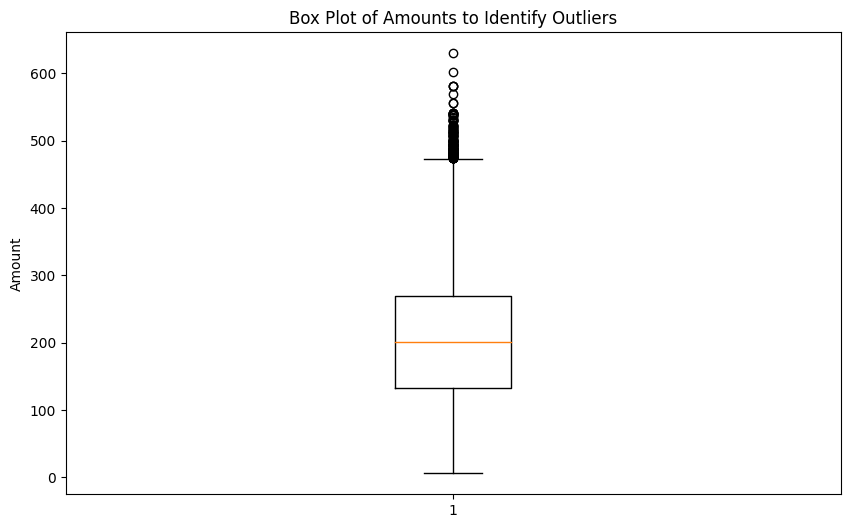

In [10]:
# Draw box plots of the 'amount' column to identify outliers
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.boxplot(df['amount'])
plt.title('Box Plot of Amounts to Identify Outliers')
plt.ylabel('Amount')
plt.show()


> It's evident that there are some outliers in the amount column.

In [7]:
# Make a copy of the dataframe and drop the tmsp column
df_no_tmsp = df.drop('tmsp', axis=1).copy()

In [8]:
# Use the IQR method to identify outliers
Q1 = df_no_tmsp['amount'].quantile(0.25)
Q3 = df_no_tmsp['amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_no_tmsp[(df_no_tmsp['amount'] < lower_bound) | (df_no_tmsp['amount'] > upper_bound)]

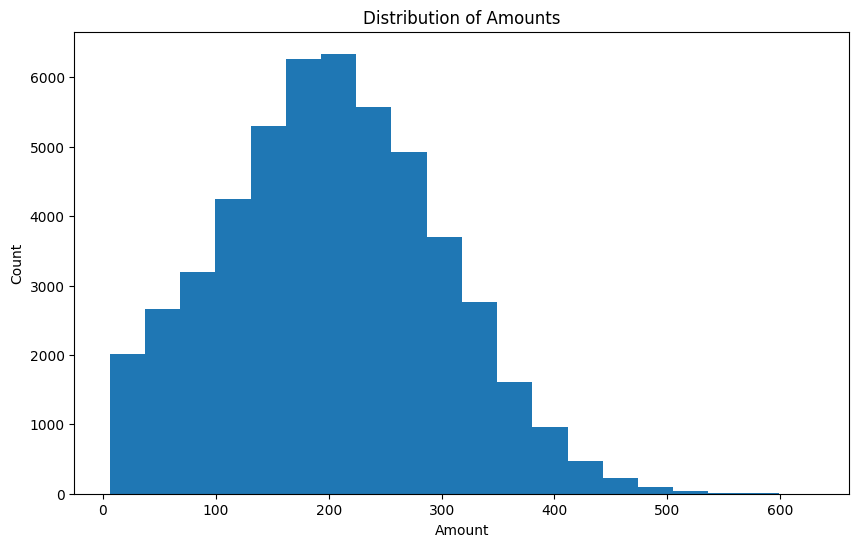

In [9]:
# Use histogram to visualize the distribution of the 'amount' column
plt.figure(figsize=(10,6))
plt.hist(df_no_tmsp['amount'], bins=20)
plt.title('Distribution of Amounts')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.show()

### Let's see which Service Provider "PSP", which card type "card" and the security status "3D_secure" have outliers

<Figure size 1000x600 with 0 Axes>

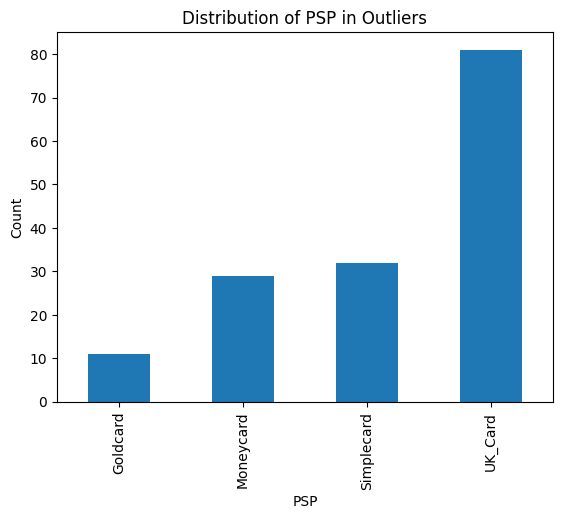

Chi-squared p-value for PSP: 1.0
Top values in PSP for positive outliers:
UK_Card       81
Simplecard    32
Moneycard     29
Goldcard      11
Name: PSP, dtype: int64


<Figure size 1000x600 with 0 Axes>

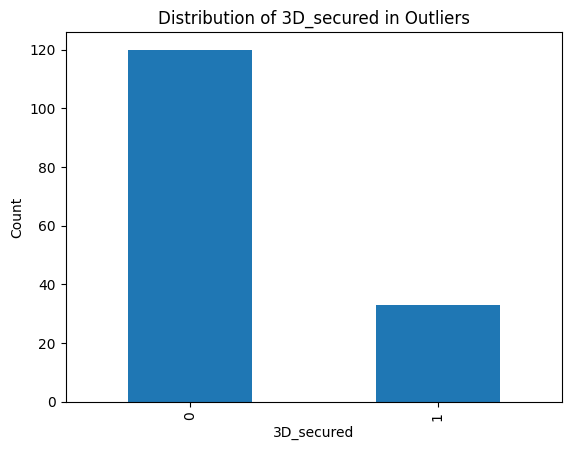

Chi-squared p-value for 3D_secured: 1.0
Top values in 3D_secured for positive outliers:
0    120
1     33
Name: 3D_secured, dtype: int64


<Figure size 1000x600 with 0 Axes>

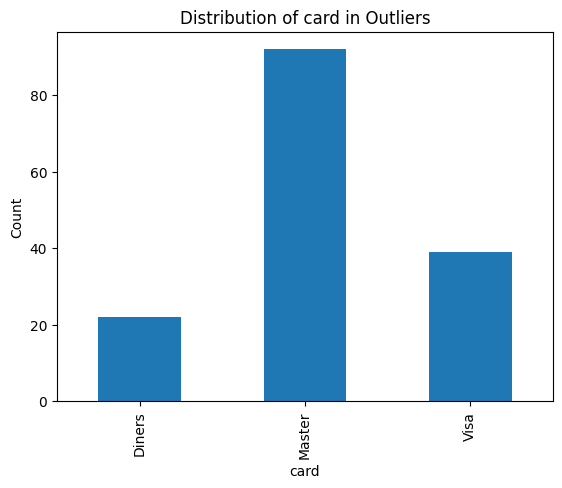

Chi-squared p-value for card: 1.0
Top values in card for positive outliers:
Master    92
Visa      39
Diners    22
Name: card, dtype: int64


<Figure size 1000x600 with 0 Axes>

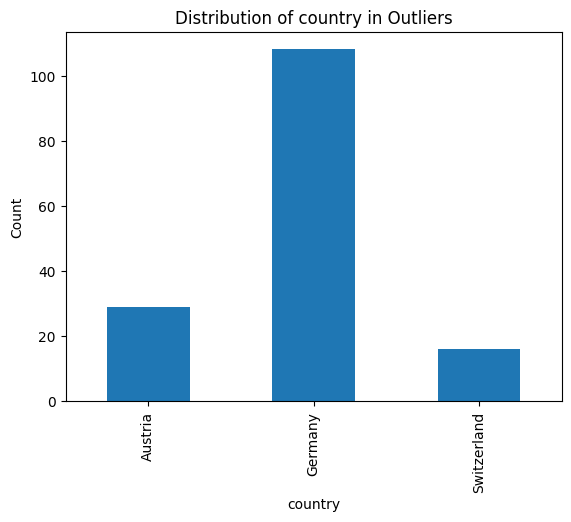

Chi-squared p-value for country: 1.0
Top values in country for positive outliers:
Germany        108
Austria         29
Switzerland     16
Name: country, dtype: int64


In [14]:
# Compare the outlier amounts with columns such as "PSP", "3D_secured", and "card"
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Step 2: Extract a subset of outliers
outlier_subset = outliers[['amount', 'PSP', '3D_secured', 'card', 'country']]

# Step 3: Analyze categorical columns
for column in ['PSP', '3D_secured', 'card', 'country']:
    # Step 4: Visualize relationships
    plt.figure(figsize=(10, 6))
    pd.crosstab(outlier_subset[column], columns='count').plot(kind='bar', legend=False)
    plt.title(f'Distribution of {column} in Outliers')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.show()

    # Step 5: Statistical testing
    contingency_table = pd.crosstab(outlier_subset[column], outliers['amount'] > 0)
    _, p_value, _, _ = chi2_contingency(contingency_table)
    print(f"Chi-squared p-value for {column}: {p_value}")

    # Step 6: Explore patterns
    print(f"Top values in {column} for positive outliers:")
    print(outliers[outliers['amount'] > 0][column].value_counts().head())

# Step 7: Consider Temporal Aspects if applicable

# Step 8: Document Insights
# Document your findings and insights from the comparison


<AxesSubplot: xlabel='success', ylabel='count'>

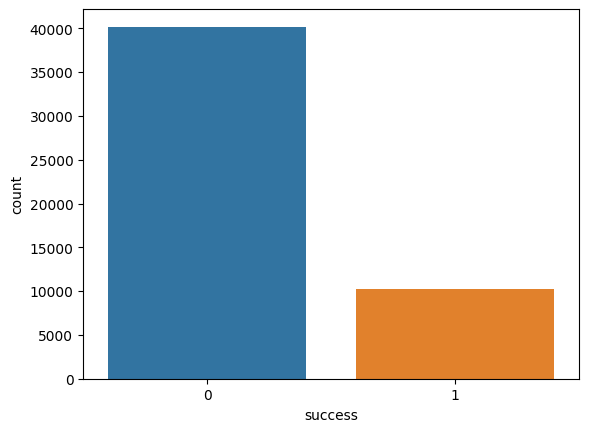

In [15]:
# Plot the distribution of success
sns.countplot(x='success', data=data)

In [16]:
# Check the success rate
print(f"Success rate: {data['success'].mean()*100:.2f}%")

Success rate: 20.29%


In [17]:
# Check success rate per country
data.groupby('country')['success'].mean()*100

country
Austria        20.459396
Germany        20.136936
Switzerland    20.574579
Name: success, dtype: float64

### Faily equal among all countries

In [18]:
# Check success rate per PSP
data.groupby('PSP')['success'].mean()*100

PSP
Goldcard      40.617207
Moneycard     21.875377
Simplecard    15.812309
UK_Card       19.433841
Name: success, dtype: float64

### The Gold has the highest success rate with the lowest being the Simplecard

In [19]:
# Check success rate per card
data.groupby('card')['success'].mean()*100

card
Diners    22.297297
Master    19.388318
Visa      20.850515
Name: success, dtype: float64

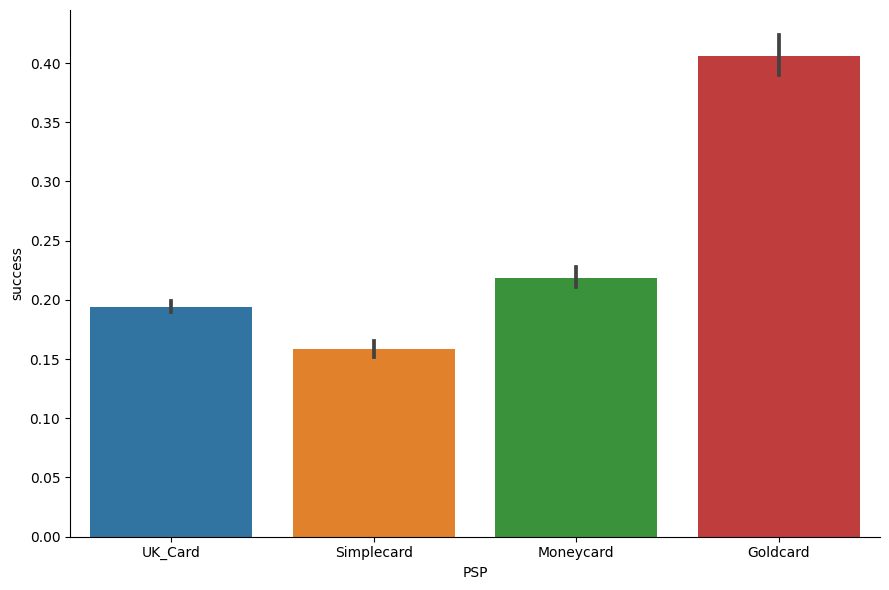

In [20]:
# Generate catplot for PSP and success
sns.catplot(x='PSP', y='success', data=data, kind='bar', height=6, aspect=1.5) 

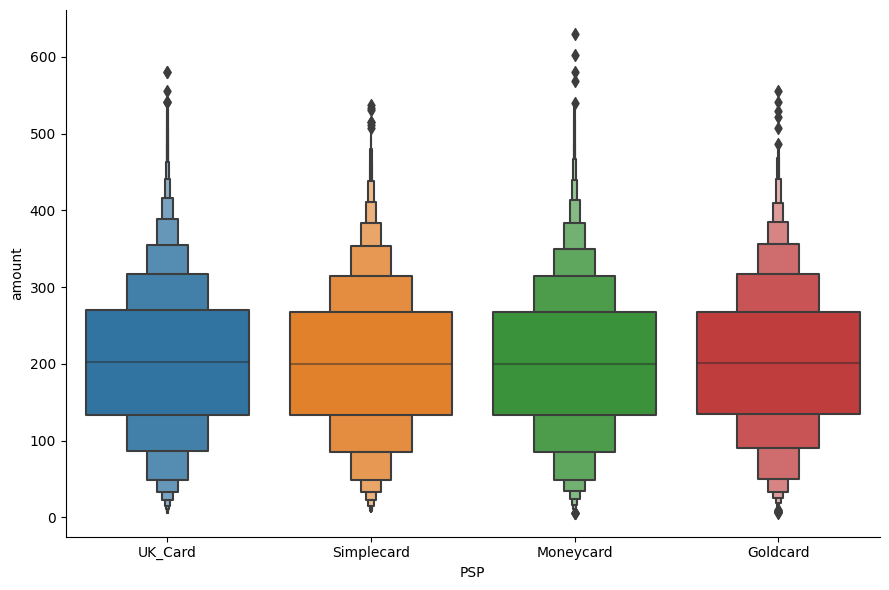

In [21]:
# Generate catplot for country and amount
sns.catplot(x='PSP', y='amount', data=data, kind= 'boxen', height=6, aspect=1.5)

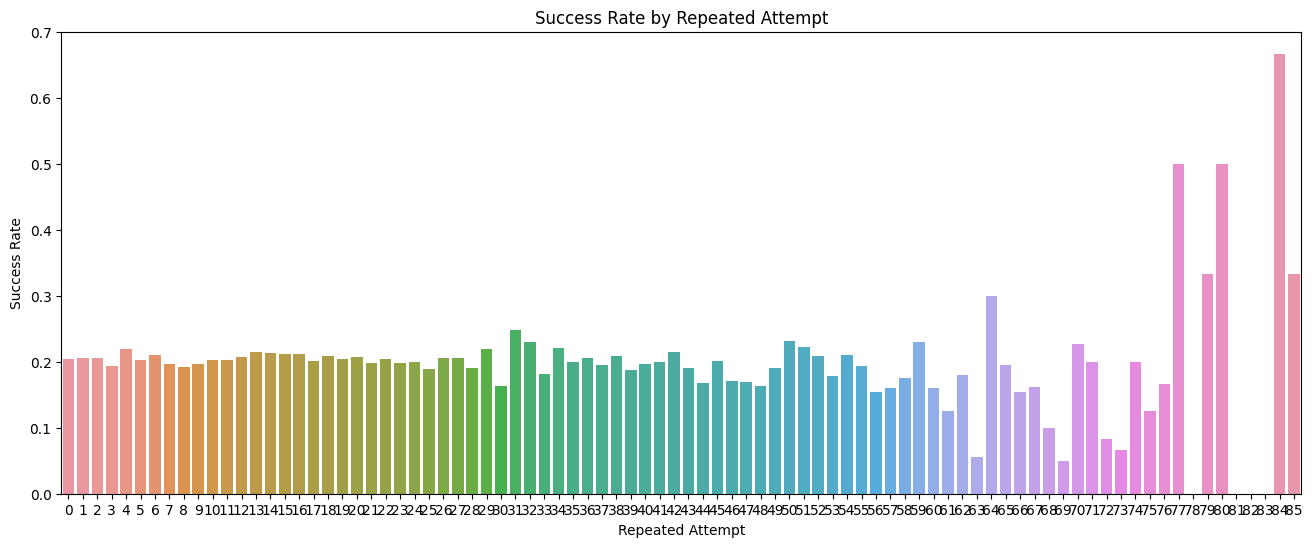

In [23]:
# Check how duplicates relate to success rate


# Set the time window and criteria
time_window = '1T'  # 1 minute
criteria_cols = ['amount', 'country']


# Calculate time difference within the time window for specified criteria
data['repeated_attempt'] = (
    data.groupby(criteria_cols, group_keys=False)
    .apply(lambda x: x['tmsp'].diff().lt(pd.to_timedelta(time_window)).astype(int).cumsum())
)

# Calculate success rate for each group
success_rate_by_attempt = (
    data.groupby('repeated_attempt')['success']
    .mean()
    .reset_index()
    .rename(columns={'success': 'success_rate'})
)

# Visualize the relationship
plt.figure(figsize=(16, 6))
sns.barplot(x='repeated_attempt', y='success_rate', data=success_rate_by_attempt)
plt.xlabel('Repeated Attempt')
plt.ylabel('Success Rate')
plt.title('Success Rate by Repeated Attempt')
plt.show()


In [24]:
# Check the relationship between success and PSP, by amount
pd.pivot_table(data, index='success', columns='PSP', values='amount', aggfunc='count')

PSP,Goldcard,Moneycard,Simplecard,UK_Card
success,,,,
0,1905,6482,10478,21317
1,1303,1815,1968,5142


## Extracting Time-related Features

In [ ]:
# Extract time-based features from the 'tmsp' column
data['hour'] = data['tmsp'].dt.hour
data['day'] = data['tmsp'].dt.day
data['month'] = data['tmsp'].dt.month
data['day_of_week'] = data['tmsp'].dt.dayofweek

In [ ]:
# Visualize the distribution of the time-based features
plt.figure(figsize=(12, 6))
sns.countplot(x='hour', hue='success', data=data)
plt.title('Distribution of Success by Hour')
plt.show()

## The GitHub Structure

In [ ]:
structure = """
├── data
│   ├── raw
│   └── processed
├── notebooks
│   ├── exploratory_data_analysis.ipynb
│   ├── modeling.ipynb
│   └── evaluation.ipynb
├── src 
│   ├── __init__.py 
│   ├── data_preprocessing.py 
│   └── modeling.py 
├── README.md
└── requirements.txt
# 
"""

print(structure)



├── data
│   ├── raw
│   └── processed
├── notebooks
│   ├── exploratory_data_analysis.ipynb
│   ├── modeling.ipynb
│   └── evaluation.ipynb
├── src 
│   ├── __init__.py 
│   ├── data_preprocessing.py 
│   └── modeling.py 
├── README.md
└── requirements.txt




<div style="text-align: center;">
    Page <!--NB_PAGE_NUMBER-->
</div>
